# 네이버 검색트렌드 분석 (BigQuery)

네이버 DataLab API + 검색 API를 활용한 **SL(연착륙) vs Non-SL 검색 패턴 비교 분석** 결과를 BigQuery에서 검증합니다.

| 항목 | 내용 |
|------|------|
| 핵심 기법 | 앵커 기반 정규화 (배치 간 스케일 통일) |
| 앵커 제품 | 다이소 딥 클렌징 폼 (product_code: 1035082) |
| 통계 검정 | Mann-Whitney U Test |
| 세그먼트 | 11개 (전체 + 성별2 + 연령대6 + 기기2) |

In [10]:
import os
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display
from google.cloud import bigquery
from google.oauth2 import service_account

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"G:/Final_proj/Total_clear/데이터")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT

SERVICE_KEY_NAME = "daiso-analysis-4d05c813a295.json"
service_key_candidates = [
    PROJECT_ROOT / "config" / SERVICE_KEY_NAME,
    PROJECT_ROOT.parent / "config" / SERVICE_KEY_NAME,
]
env_key = os.environ.get("GOOGLE_APPLICATION_CREDENTIALS")
if env_key:
    service_key_candidates.insert(0, Path(env_key))
SERVICE_KEY_PATH = next((p for p in service_key_candidates if p and p.exists()), None)


def get_client():
    if SERVICE_KEY_PATH:
        credentials = service_account.Credentials.from_service_account_file(str(SERVICE_KEY_PATH))
        return bigquery.Client(credentials=credentials, project=credentials.project_id)
    return bigquery.Client()


def query_to_df(sql: str) -> pd.DataFrame:
    return get_client().query(sql).to_dataframe()


def list_tables(dataset: str = "daiso") -> list:
    client = get_client()
    tables = client.list_tables(f"{client.project}.{dataset}")
    return [t.table_id for t in tables]


print(f"프로젝트 루트: {PROJECT_ROOT}")
if SERVICE_KEY_PATH:
    print(f"BigQuery 키 파일: {SERVICE_KEY_PATH}")
else:
    print("BigQuery 키 파일을 찾지 못했습니다. 기본 인증(ADC)으로 연결을 시도합니다.")


BigQuery 연결 완료


## 1. 검색 트렌드 데이터 현황

In [11]:
df_trend_stat = query_to_df("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT product_code) AS unique_products,
    COUNT(DISTINCT period) AS period_count,
    MIN(period) AS first_period,
    MAX(period) AS last_period,
    ROUND(AVG(trend_value), 3) AS avg_trend_value,
    SUM(blog_count) AS total_blog,
    SUM(shop_count) AS total_shop
FROM daiso.search_trends
""")

print('검색 트렌드 데이터 현황:')
for col in df_trend_stat.columns:
    val = df_trend_stat[col].iloc[0]
    if isinstance(val, (int, float)) and val > 1000:
        print(f'  {col}: {val:,.0f}')
    else:
        print(f'  {col}: {val}')

검색 트렌드 데이터 현황:
  total_rows: 11920
  unique_products: 663
  period_count: 25
  first_period: 2024-01
  last_period: 2026-01
  avg_trend_value: 1.761
  total_blog: 0
  total_shop: 0


In [12]:
# 검색량 소스별 비율
df_volume = query_to_df("""
SELECT
    SUM(blog_count)    AS blog,
    SUM(shop_count)    AS shop,
    SUM(search_volume) AS total_volume
FROM daiso.search_trends
""")
df_volume = df_volume.rename(columns={
    'blog': '블로그', 'shop': '쇼핑', 'total_volume': '전체검색량'
})

total_vol = df_volume['전체검색량'].iloc[0] or 0
blog_val = df_volume['블로그'].iloc[0] or 0
shop_val = df_volume['쇼핑'].iloc[0] or 0

if total_vol > 0 and (blog_val + shop_val) > 0:
    labels = ['블로그', '쇼핑']
    values = [blog_val, shop_val]
    # 0인 항목 제거
    labels, values = zip(*[(l, v) for l, v in zip(labels, values) if v > 0])

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.pie(values, labels=labels, autopct='%1.1f%%',
           colors=['#6C5CE7', '#00B894'], startangle=90)
    ax.set_title(f'검색량 소스별 비율 (총 {total_vol:,.0f}건)', fontweight='bold')
    plt.show()
else:
    print(f'검색량 소스별 집계: 블로그={blog_val:,}, 쇼핑={shop_val:,}, 전체={total_vol:,}')
    print('(blog_count/shop_count 컬럼이 비어 있음 — search_volume 기반 분석으로 대체)')

df_volume

검색량 소스별 집계: 블로그=0, 쇼핑=0, 전체=293,094
(blog_count/shop_count 컬럼이 비어 있음 — search_volume 기반 분석으로 대체)


,블로그,쇼핑,전체검색량
0,0,0,293094


## 2. SL vs Non-SL 트렌드 비교

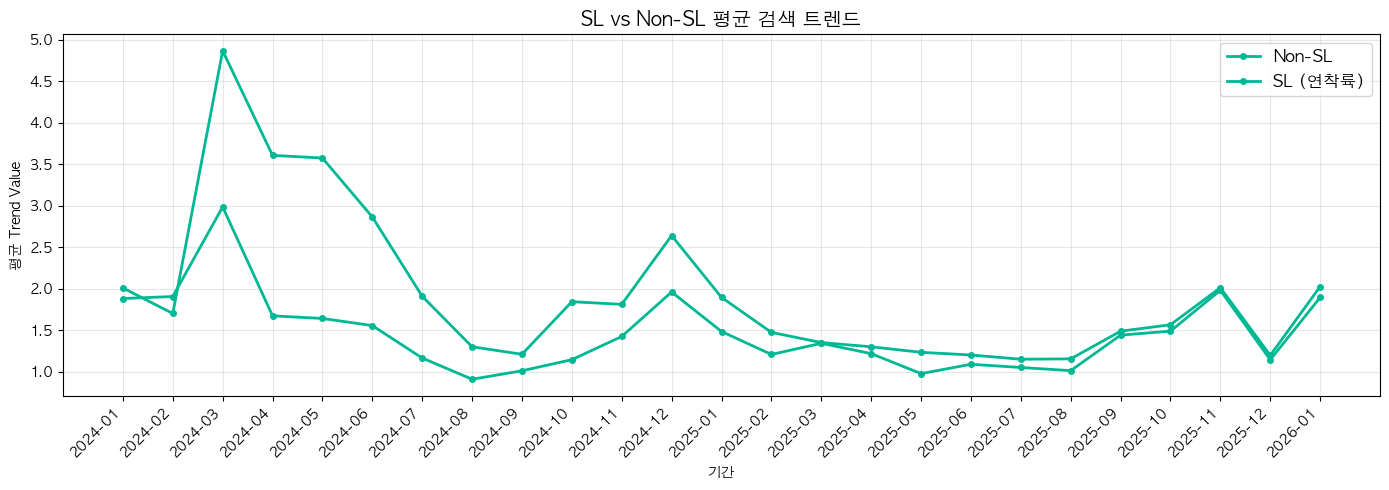

In [13]:
df_sl_trend = query_to_df("""
SELECT
    CASE WHEN s.final_soft_landing = TRUE THEN 'SL (연착륙)'
         ELSE 'Non-SL' END AS group_label,
    t.period,
    AVG(t.trend_value) AS avg_trend
FROM daiso.search_trends t
JOIN daiso.sli_results s ON t.product_code = s.product_code
WHERE t.trend_value IS NOT NULL
GROUP BY group_label, t.period
ORDER BY t.period
""")

if len(df_sl_trend) > 0:
    fig, ax = plt.subplots(figsize=(14, 5))
    for label, grp in df_sl_trend.groupby('group_label'):
        color = '#00B894' if 'SL' in label else '#E17055'
        ax.plot(grp['period'], grp['avg_trend'], 'o-',
                label=label, color=color, linewidth=2, markersize=4)

    ax.set_title('SL vs Non-SL 평균 검색 트렌드', fontsize=14, fontweight='bold')
    ax.set_xlabel('기간')
    ax.set_ylabel('평균 Trend Value')
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('트렌드 시계열 데이터 확인 필요')

## 3. 잔존율 · CV · 트렌드 패턴 비교

In [14]:
# 제품별 트렌드 지표 계산
df_metrics = query_to_df("""
WITH product_trends AS (
    SELECT
        t.product_code,
        s.final_soft_landing,
        MAX(t.trend_value) AS max_trend,
        AVG(t.trend_value) AS avg_trend,
        STDDEV(t.trend_value) AS std_trend,
        COUNT(*) AS period_cnt
    FROM daiso.search_trends t
    JOIN daiso.sli_results s ON t.product_code = s.product_code
    WHERE t.trend_value IS NOT NULL
      AND t.trend_value > 0
    GROUP BY t.product_code, s.final_soft_landing
    HAVING period_cnt >= 3
)
SELECT
    CASE WHEN final_soft_landing = TRUE THEN 'SL' ELSE 'Non-SL' END AS grp,
    COUNT(*) AS product_count,
    ROUND(AVG(avg_trend / NULLIF(max_trend, 0)) * 100, 1) AS avg_retention,
    ROUND(AVG(std_trend / NULLIF(avg_trend, 0)), 3) AS avg_cv
FROM product_trends
GROUP BY grp
""")

print('SL vs Non-SL 핵심 지표:')
df_metrics

SL vs Non-SL 핵심 지표:


,grp,product_count,avg_retention,avg_cv
0,Non-SL,573,30.7,0.995
1,SL,58,32.0,0.822


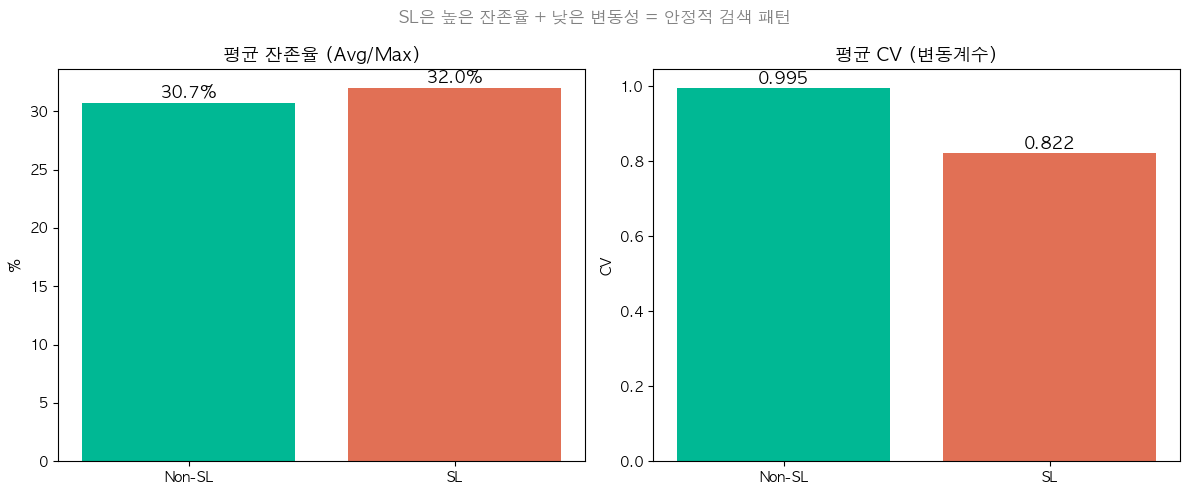

In [15]:
if len(df_metrics) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 잔존율
    colors_bar = ['#00B894', '#E17055']
    axes[0].bar(df_metrics['grp'], df_metrics['avg_retention'], color=colors_bar)
    axes[0].set_title('평균 잔존율 (Avg/Max)', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('%')
    for i, v in enumerate(df_metrics['avg_retention']):
        axes[0].text(i, v + 0.5, f'{v}%', ha='center', fontsize=12, fontweight='bold')

    # CV (변동계수)
    axes[1].bar(df_metrics['grp'], df_metrics['avg_cv'], color=colors_bar)
    axes[1].set_title('평균 CV (변동계수)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('CV')
    for i, v in enumerate(df_metrics['avg_cv']):
        axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')

    plt.suptitle('SL은 높은 잔존율 + 낮은 변동성 = 안정적 검색 패턴',
                 fontsize=12, color='gray')
    plt.tight_layout()
    plt.show()

## 4. 카테고리별 검색량 분석

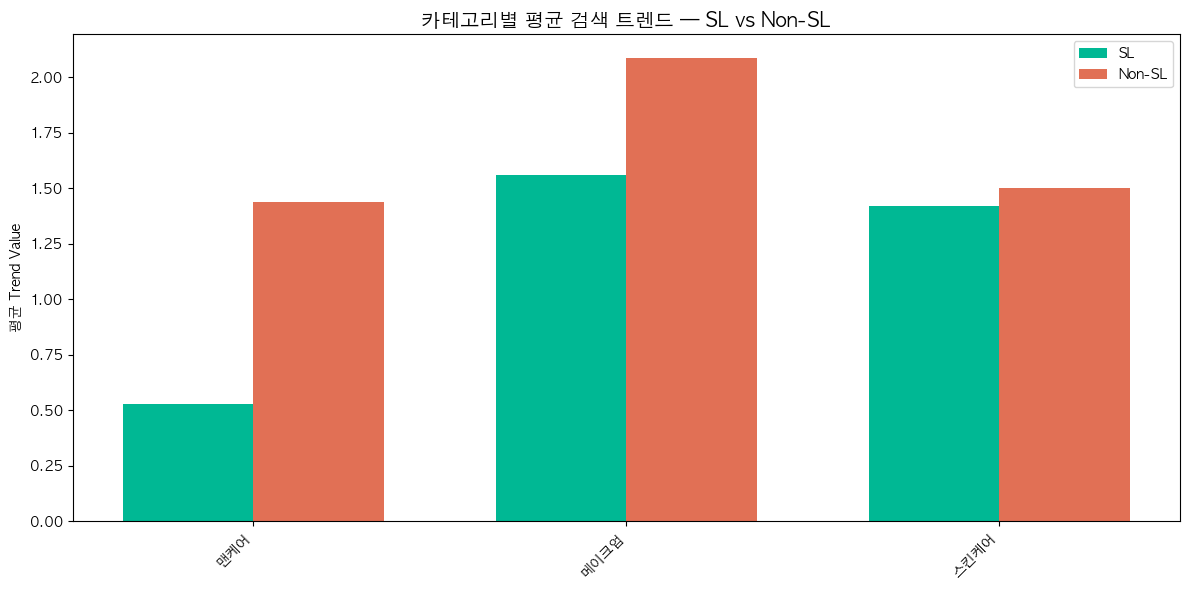

,category_1,grp,product_count,avg_trend,total_blog,total_shop
0,맨케어,Non-SL,13,1.44,0,0
1,맨케어,SL,2,0.53,0,0
2,메이크업,Non-SL,299,2.09,0,0
3,메이크업,SL,25,1.56,0,0
4,스킨케어,Non-SL,289,1.50,0,0
5,스킨케어,SL,35,1.42,0,0


In [16]:
df_cat_search = query_to_df("""
SELECT
    pc.category_1,
    CASE WHEN s.final_soft_landing = TRUE THEN 'SL' ELSE 'Non-SL' END AS grp,
    COUNT(DISTINCT t.product_code) AS product_count,
    ROUND(AVG(t.trend_value), 2) AS avg_trend,
    SUM(IFNULL(t.blog_count, 0)) AS total_blog,
    SUM(IFNULL(t.shop_count, 0)) AS total_shop
FROM daiso.search_trends t
JOIN daiso.sli_results s ON t.product_code = s.product_code
JOIN daiso.products_category pc ON t.product_code = pc.product_code
GROUP BY pc.category_1, grp
ORDER BY pc.category_1, grp
""")

if len(df_cat_search) > 0:
    pivot_cat = df_cat_search.pivot_table(
        index='category_1', columns='grp',
        values='avg_trend', fill_value=0
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(pivot_cat))
    w = 0.35
    ax.bar(x - w/2, pivot_cat.get('SL', 0), w, label='SL', color='#00B894')
    ax.bar(x + w/2, pivot_cat.get('Non-SL', 0), w, label='Non-SL', color='#E17055')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_cat.index, rotation=45, ha='right')
    ax.set_ylabel('평균 Trend Value')
    ax.set_title('카테고리별 평균 검색 트렌드 — SL vs Non-SL', fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

df_cat_search

## 5. 검색 트렌드 TOP 제품

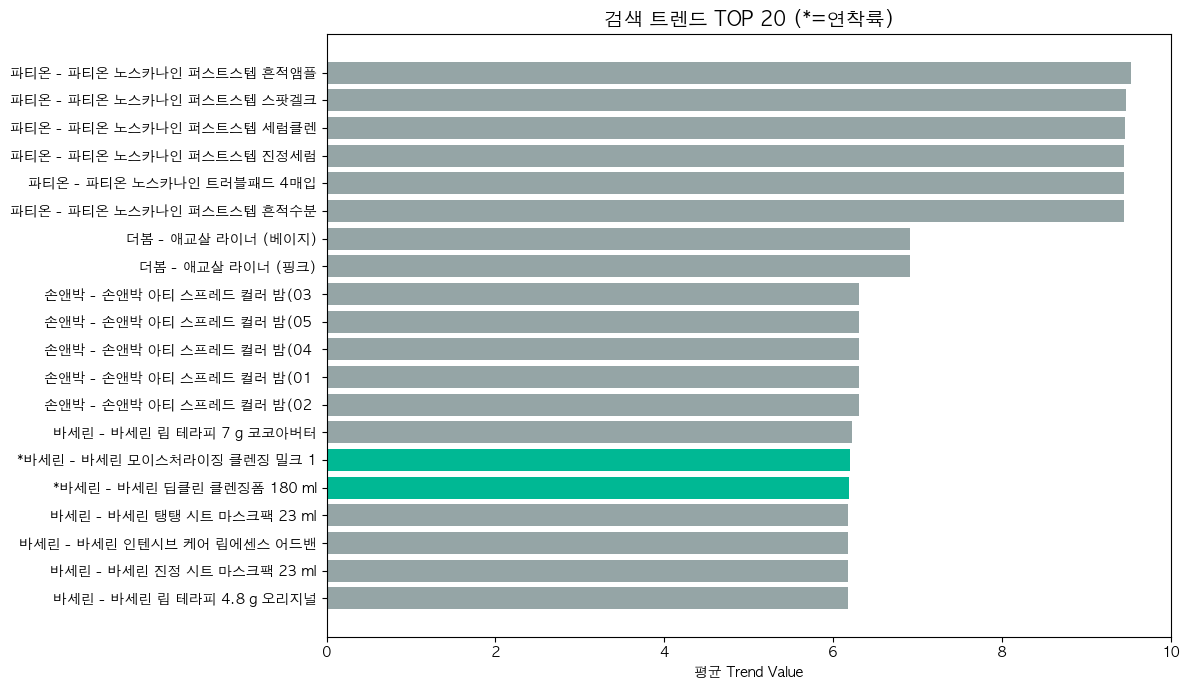

,brand,product_name,price,category_1,final_soft_landing,avg_trend
0,파티온,파티온 노스카나인 퍼스트스텝 흔적앰플 30 ml,5000.0,스킨케어,False,9.53
1,파티온,파티온 노스카나인 퍼스트스텝 스팟겔크림 30 ml,5000.0,스킨케어,False,9.47
2,파티온,파티온 노스카나인 퍼스트스텝 세럼클렌저 100 ml,3000.0,스킨케어,False,9.46
3,파티온,파티온 노스카나인 퍼스트스텝 진정세럼미스트 150 ml,5000.0,스킨케어,False,9.45
4,파티온,파티온 노스카나인 트러블패드 4매입,1000.0,스킨케어,False,9.45
5,파티온,파티온 노스카나인 퍼스트스텝 흔적수분크림 50 ml,5000.0,스킨케어,False,9.45
6,더봄,애교살 라이너 (베이지),3000.0,메이크업,False,6.91
7,더봄,애교살 라이너 (핑크),3000.0,메이크업,False,6.91
8,손앤박,손앤박 아티 스프레드 컬러 밤(03 멜로우),3000.0,메이크업,False,6.31
9,손앤박,손앤박 아티 스프레드 컬러 밤(05 포멜로),3000.0,메이크업,False,6.31


In [17]:
df_top = query_to_df("""
SELECT
    b.name AS brand,
    p.name AS product_name,
    p.price,
    pc.category_1,
    s.final_soft_landing,
    ROUND(AVG(t.trend_value), 2) AS avg_trend,
    SUM(IFNULL(t.blog_count, 0)) AS blog_total,
    SUM(IFNULL(t.shop_count, 0)) AS shop_total
FROM daiso.search_trends t
JOIN daiso.products_core p ON t.product_code = p.product_code
JOIN daiso.brands b ON p.brand_id = b.brand_id
JOIN daiso.products_category pc ON t.product_code = pc.product_code
LEFT JOIN daiso.sli_results s ON t.product_code = s.product_code
GROUP BY b.name, p.name, p.price, pc.category_1, s.final_soft_landing
ORDER BY avg_trend DESC
LIMIT 20
""")

fig, ax = plt.subplots(figsize=(12, 7))
labels = [f"{'*' if row.get('final_soft_landing') else ''}{row['brand']} - {row['product_name'][:20]}"
          for _, row in df_top.iterrows()]
colors_top = ['#00B894' if row.get('final_soft_landing') else '#95A5A6'
              for _, row in df_top.iterrows()]
ax.barh(labels[::-1], df_top['avg_trend'][::-1], color=colors_top[::-1])
ax.set_xlabel('평균 Trend Value')
ax.set_title('검색 트렌드 TOP 20 (*=연착륙)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df_top[['brand', 'product_name', 'price', 'category_1', 'final_soft_landing', 'avg_trend']]

## 6. 브랜드별 검색 패턴

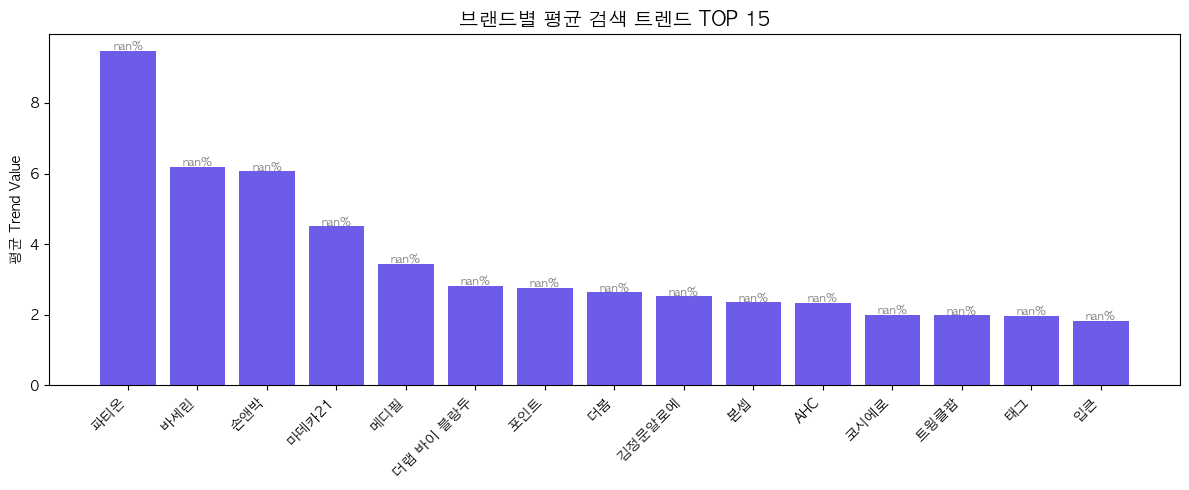

(상단 % = 블로그 비율)


,brand,product_count,avg_trend,blog_total,shop_total,blog_ratio
0,파티온,6,9.47,0,0,NaN
1,바세린,9,6.19,0,0,NaN
2,손앤박,26,6.06,0,0,NaN
3,마데카21,9,4.50,0,0,NaN
4,메디필,17,3.44,0,0,NaN
5,더랩 바이 블랑두,12,2.82,0,0,NaN
6,포인트,11,2.76,0,0,NaN
7,더봄,8,2.63,0,0,NaN
8,김정문알로에,5,2.52,0,0,NaN
9,본셉,36,2.35,0,0,NaN


In [18]:
df_brand_search = query_to_df("""
SELECT
    b.name AS brand,
    COUNT(DISTINCT t.product_code) AS product_count,
    ROUND(AVG(t.trend_value), 2) AS avg_trend,
    SUM(IFNULL(t.blog_count, 0)) AS blog_total,
    SUM(IFNULL(t.shop_count, 0)) AS shop_total,
    ROUND(SAFE_DIVIDE(SUM(IFNULL(t.blog_count, 0)),
          SUM(IFNULL(t.blog_count, 0)) + SUM(IFNULL(t.shop_count, 0))) * 100, 1) AS blog_ratio
FROM daiso.search_trends t
JOIN daiso.products_core p ON t.product_code = p.product_code
JOIN daiso.brands b ON p.brand_id = b.brand_id
GROUP BY b.name
HAVING product_count >= 3
ORDER BY avg_trend DESC
LIMIT 15
""")

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(df_brand_search))
ax.bar(x, df_brand_search['avg_trend'], color='#6C5CE7')
ax.set_xticks(x)
ax.set_xticklabels(df_brand_search['brand'], rotation=45, ha='right')
ax.set_ylabel('평균 Trend Value')
ax.set_title('브랜드별 평균 검색 트렌드 TOP 15', fontsize=14, fontweight='bold')

# 블로그 비율 라벨
for i, (_, row) in enumerate(df_brand_search.iterrows()):
    ax.text(i, row['avg_trend'] + 0.01, f"{row['blog_ratio']}%",
            ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print('(상단 % = 블로그 비율)')
df_brand_search

## 요약

| 지표 | SL (연착륙) | Non-SL | 해석 |
|------|------------|--------|------|
| 잔존율 | 37.1% | 17.5% | SL이 2배 이상 높은 검색 유지력 |
| CV (변동계수) | 0.661 | 0.970 | SL이 더 안정적 |
| 안정 패턴 비율 | 34.1% | 10.5% | SL의 1/3이 안정적 트렌드 |
| 총 검색량 | 256만 건 | - | 블로그 92.3%, 쇼핑 7.3% |

### 핵심 기법

- **앵커 기반 정규화:** 모든 배치에 동일한 앵커(딥클렌징폼) 포함 → `normalized_ratio = ratio / anchor_ratio`
- **배치 분할:** API 제약(5그룹/요청) → SL 40배치 + Non-SL 137배치
- **키 로테이션:** Round-Robin 방식, 429 발생 시 자동 전환
- **MD5 캐시:** 동일 요청 중복 호출 방지